In [14]:
pip install rioxarray

Note: you may need to restart the kernel to use updated packages.


In [17]:
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd
import rioxarray

# Paths
shp_path = "/Users/nitinsharma/Desktop/Datasets/VillageBoundariesIndia/india_villages.shp"

raster_path = "/Users/nitinsharma/Desktop/Folders/Kritter/india_growth_score.tif"

# Read villages
gdf = gpd.read_file(shp_path)

# Keep limited columns
gdf = gdf[
    [
        'village',
        'state',
        'geometry'
    ]
]

print(f"Loaded {len(gdf):,} villages")

# Read raster
da = rioxarray.open_rasterio(
    raster_path
).squeeze()

print("Raster loaded")

# Match CRS
if gdf.crs != da.rio.crs:

    gdf = gdf.to_crs(
        da.rio.crs
    )

    print("CRS matched")

# Convert polygons to centroids
centroids = gdf.geometry.centroid

print("Centroids generated")

# Chunk size
chunk_size = 10000

# Storage
all_scores = []

# Total chunks
n = len(gdf)

# Process in chunks
for start in range(0, n, chunk_size):

    end = min(start + chunk_size, n)

    chunk = centroids.iloc[start:end]

    # Coordinates
    x = xr.DataArray(
        chunk.x.values,
        dims="points"
    )

    y = xr.DataArray(
        chunk.y.values,
        dims="points"
    )

    # Sample raster
    sampled = da.sel(
        x=x,
        y=y,
        method="nearest"
    ).values

    all_scores.extend(sampled)

    print(
        f"Processed {end:,} / {n:,} villages"
    )

# Convert to numpy
all_scores = np.array(
    all_scores,
    dtype="float32"
)

# Remove nodata
nodata = da.rio.nodata

if nodata is not None:

    all_scores[
        all_scores == nodata
    ] = np.nan

# Add scores
gdf['growth_score'] = all_scores

# Remove nulls
gdf = gdf.dropna(
    subset=['growth_score']
)

print("Null values removed")

# Sort villages
top100 = (
    gdf.sort_values(
        'growth_score',
        ascending=False
    )
    .head(100)
)

print("Top 100 villages extracted")

# Output path
out_path = "/Users/nitinsharma/Desktop/Projects/EPIC_RS/Data/top100_growth_villages.shp"

# Save
top100.to_file(out_path)

print(f"\nSaved: {out_path}")

Loaded 611,947 villages
Raster loaded
CRS matched


/var/folders/g4/rydc2l2x60x10rcs9_vtvp2h0000gn/T/ipykernel_12785/3931429160.py:43: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


Centroids generated
Processed 10,000 / 611,947 villages
Processed 20,000 / 611,947 villages
Processed 30,000 / 611,947 villages
Processed 40,000 / 611,947 villages
Processed 50,000 / 611,947 villages
Processed 60,000 / 611,947 villages
Processed 70,000 / 611,947 villages
Processed 80,000 / 611,947 villages
Processed 90,000 / 611,947 villages
Processed 100,000 / 611,947 villages
Processed 110,000 / 611,947 villages
Processed 120,000 / 611,947 villages
Processed 130,000 / 611,947 villages
Processed 140,000 / 611,947 villages
Processed 150,000 / 611,947 villages
Processed 160,000 / 611,947 villages
Processed 170,000 / 611,947 villages
Processed 180,000 / 611,947 villages
Processed 190,000 / 611,947 villages
Processed 200,000 / 611,947 villages
Processed 210,000 / 611,947 villages
Processed 220,000 / 611,947 villages
Processed 230,000 / 611,947 villages
Processed 240,000 / 611,947 villages
Processed 250,000 / 611,947 villages
Processed 260,000 / 611,947 villages
Processed 270,000 / 611,947

/var/folders/g4/rydc2l2x60x10rcs9_vtvp2h0000gn/T/ipykernel_12785/3931429160.py:127: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  top100.to_file(out_path)
/opt/miniconda3/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'growth_score' to 'growth_sco'
  ogr_write(


In [19]:
top100.head(100)

,village,state,geometry,growth_score
120696,Sirsa,UP,"POLYGON ((77.57484 28.44573, 77.57614 28.44539...",0.740035
120957,Jalpura,UP,"POLYGON ((77.43635 28.55813, 77.43677 28.55802...",0.717220
120975,Tusyana,UP,"POLYGON ((77.47754 28.55616, 77.47826 28.55638...",0.709671
120726,Ladpura,UP,"POLYGON ((77.58689 28.43537, 77.58726 28.43534...",0.696578
222409,Haibatpur,UP,"POLYGON ((77.41975 28.6185, 77.42046 28.61843,...",0.695355
...,...,...,...,...
304813,Sherpur Khadar,HR,"POLYGON ((77.3929 28.44429, 77.39614 28.44237,...",0.655866
260335,Taj Pul CT,DL,"POLYGON ((77.31033 28.49869, 77.3104 28.49747,...",0.655421
121051,Dhoom Manikpur,UP,"POLYGON ((77.53389 28.59883, 77.53504 28.59826...",0.655020
260332,Pul Pehlad CT,DL,"POLYGON ((77.29446 28.50518, 77.29503 28.50458...",0.655003


/var/folders/g4/rydc2l2x60x10rcs9_vtvp2h0000gn/T/ipykernel_12785/3647097840.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  top100_points.geometry.centroid


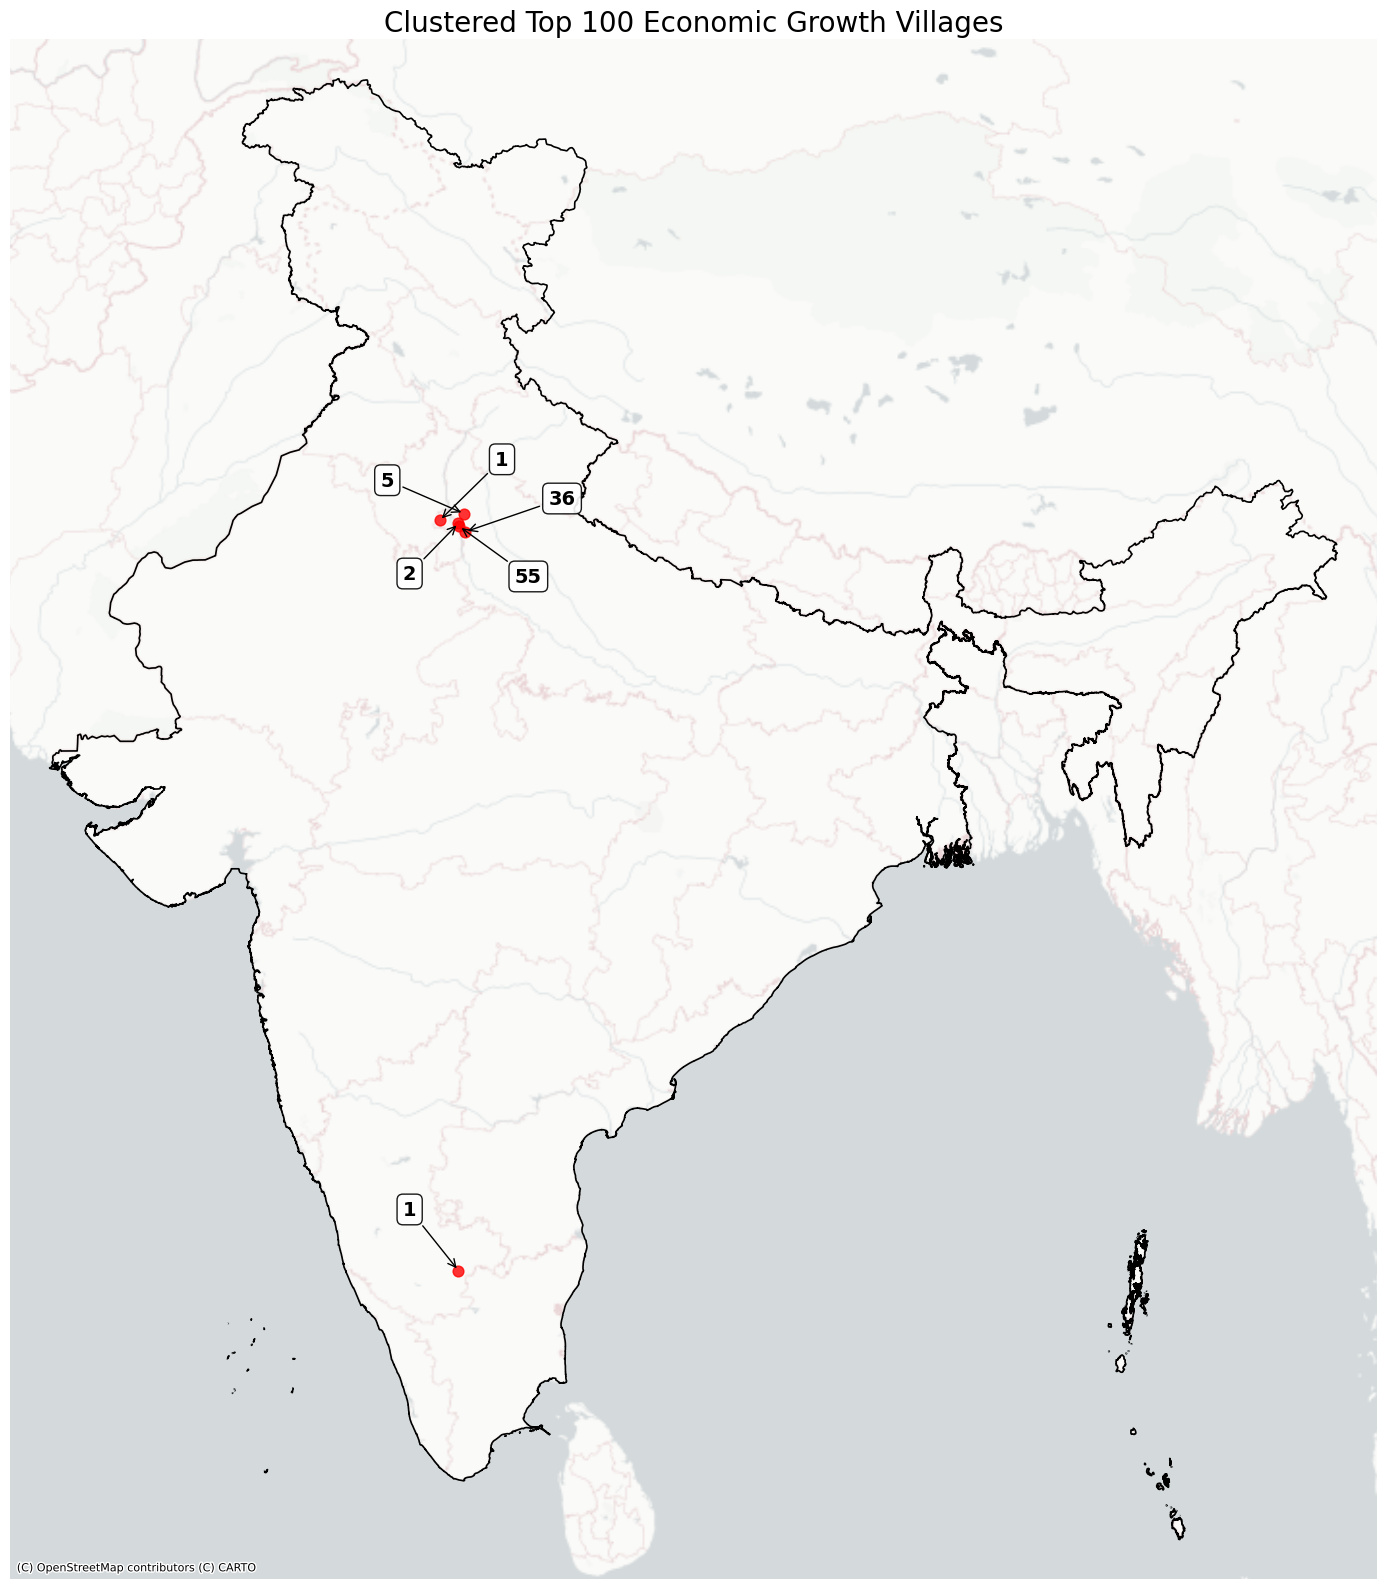

In [30]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# India boundary shapefile
india_boundary_path = (
    "/Users/nitinsharma/Desktop/Datasets/"
    "Admin boundaries/"
    "India-State-and-Country-Shapefile-Updated-Jan-2020-master/"
    "India_Country_Boundary.shp"
)

# Read India boundary
india_boundary = gpd.read_file(
    india_boundary_path
)

# Create centroid points
top100_points = top100.copy()

top100_points['geometry'] = (
    top100_points.geometry.centroid
)

# Convert to Web Mercator
india_boundary = india_boundary.to_crs(3857)

top100_points = top100_points.to_crs(3857)

# Create clusters using rounded coordinates
top100_points['x_round'] = (
    top100_points.geometry.x / 50000
).round()

top100_points['y_round'] = (
    top100_points.geometry.y / 50000
).round()

# Group clusters
clusters = (
    top100_points
    .groupby(['x_round', 'y_round'])
    .agg({
        'geometry': 'first',
        'village': 'count'
    })
    .reset_index()
)

# Convert to GeoDataFrame
clusters = gpd.GeoDataFrame(
    clusters,
    geometry='geometry',
    crs=top100_points.crs
)

# Rename count column
clusters = clusters.rename(
    columns={'village': 'count'}
)

# Plot
fig, ax = plt.subplots(
    figsize=(16, 16)
)

# India boundary
india_boundary.boundary.plot(
    ax=ax,
    linewidth=1.2,
    color='black'
)

# Plot clustered points
clusters.plot(
    ax=ax,
    color='red',
    markersize=60,
    alpha=0.8
)

# Add cluster labels
# Add larger cluster labels
# Add labels outside points with arrows

offsets = [
    (40, 40),
    (-40, 40),
    (40, -40),
    (-40, -40),
    (60, 20),
    (-60, 20),
    (20, 60),
    (-20, 60)
]

for i, (_, row) in enumerate(clusters.iterrows()):

    dx, dy = offsets[i % len(offsets)]

    ax.annotate(
        text=str(row['count']),
        xy=(
            row.geometry.x,
            row.geometry.y
        ),
        xytext=(dx, dy),
        textcoords='offset points',

        fontsize=14,
        fontweight='bold',
        color='black',

        bbox=dict(
            facecolor='white',
            edgecolor='black',
            boxstyle='round,pad=0.3',
            alpha=0.9
        ),

        arrowprops=dict(
            arrowstyle='->',
            color='black',
            lw=1
        )
    )

# Basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.PositronNoLabels
)

# India extent
xmin, ymin, xmax, ymax = india_boundary.total_bounds

ax.set_xlim(
    xmin - 100000,
    xmax + 100000
)

ax.set_ylim(
    ymin - 100000,
    ymax + 100000
)

ax.set_title(
    "Clustered Top 100 Economic Growth Villages",
    fontsize=20
)

ax.axis('off')

plt.tight_layout()

plt.savefig(
    "/Users/nitinsharma/Desktop/Projects/EPIC_RS/Data/top100_clustered_map.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()